首先，我们将导入必要的库，并根据定义的数学函数生成数据集。
为了后续可视化预测曲线的平滑度，我们在生成随机点后，会专门生成一组等间距的测试点用于最终画图。

In [1]:
import numpy as np
import matplotlib.pyplot as plt


# 1. 定义目标函数
def target_function(x):
    return np.sin(3 * np.pi * x) + 0.5 * x**2


# 2. 采集数据
np.random.seed(42)  # 固定随机种子以保证结果可复现
num_samples = 2000

# 在 [-1, 1] 之间均匀采样
X_data = np.random.uniform(-1, 1, (num_samples, 1))
y_data = target_function(X_data)

# 3. 划分训练集和测试集 (80% 训练，20% 测试)
# 打乱索引
indices = np.random.permutation(num_samples)
train_size = int(0.8 * num_samples)

train_indices = indices[:train_size]
test_indices = indices[train_size:]

X_train, y_train = X_data[train_indices], y_data[train_indices]
X_test, y_test = X_data[test_indices], y_data[test_indices]

# 为了画图平滑，专门生成一个有序的测试集
X_plot = np.linspace(-1, 1, 500).reshape(-1, 1)
y_plot_true = target_function(X_plot)

print(f"训练集特征维度: {X_train.shape}, 标签维度: {y_train.shape}")
print(f"测试集特征维度: {X_test.shape}, 标签维度: {y_test.shape}")

训练集特征维度: (1600, 1), 标签维度: (1600, 1)
测试集特征维度: (400, 1), 标签维度: (400, 1)


回归任务的网络架构：
隐藏层：使用 ReLU，将一维输入映射到高维空间并截断产生非线性。
输出层：只有一个节点，不使用激活函数，直接输出 $Z^{[2]}$。
损失函数 (MSE)：
$$J = \frac{1}{2m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})^2$$
反向传播的核心在于输出层误差 $dZ^{[2]}$：
因为 $\hat{y} = Z^{[2]}$，根据链式法则对 MSE 求导：
$$dZ^{[2]} = \frac{1}{m}(\hat{y} - y)$$
(注：为了在更新参数时保持代码整洁，我们将 $\frac{1}{m}$ 提取到了 $dZ^{[2]}$ 的计算中，后续的 $dW$ 和 $db$ 计算就不需要再额外除以 $m$ 了。)

In [10]:
def init_params(input_size=1, hidden_size=512, output_size=1):
    # He 初始化 (针对 ReLU 优化)
    W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2.0 / input_size)
    b1 = np.zeros((1, hidden_size))
    # Xavier 初始化 (适用于线性输出)
    W2 = np.random.randn(hidden_size, output_size) * np.sqrt(1.0 / hidden_size)
    b2 = np.zeros((1, output_size))
    return W1, b1, W2, b2


def relu(Z):
    return np.maximum(0, Z)


def relu_deriv(Z):
    return Z > 0


def compute_mse(y_pred, y_true):
    return np.mean(0.5 * (y_pred - y_true) ** 2)


def forward_prop(W1, b1, W2, b2, X):
    Z1 = np.dot(X, W1) + b1
    A1 = relu(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = Z2  # 线性输出层
    return Z1, A1, Z2, A2


def backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y):
    m = X.shape[0]

    # MSE 的导数，注意这里直接除以了 m
    dZ2 = (A2 - Y) / m
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * relu_deriv(Z1)
    dW1 = np.dot(X.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    return dW1, db1, dW2, db2


def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate):
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    return W1, b1, W2, b2

回归任务有时比分类任务更难收敛。
为了拟合这种具有多个波峰波谷的函数，我们需要稍微增加隐藏层的神经元数量（这里设为 256），并增加迭代次数。

In [14]:
def train_regression_network(X, Y, epochs=10000, learning_rate=0.1):
    # 使用 256 个神经元来确保足够的拟合能力
    W1, b1, W2, b2 = init_params(1, 256, 1)
    train_loss_history = []

    for i in range(epochs):
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        loss = compute_mse(A2, Y)
        train_loss_history.append(loss)

        dW1, db1, dW2, db2 = backward_prop(Z1, A1, Z2, A2, W1, W2, X, Y)
        W1, b1, W2, b2 = update_params(
            W1, b1, W2, b2, dW1, db1, dW2, db2, learning_rate
        )

        if i % 1000 == 0:
            print(f"Epoch {i:5d} | MSE Loss: {loss:.6f}")

    return W1, b1, W2, b2, train_loss_history


print("开始训练模型...")
# 训练过程可能需要几秒到十几秒
W1, b1, W2, b2, loss_history = train_regression_network(
    X_train, y_train, epochs=50000, learning_rate=0.05
)

开始训练模型...
Epoch     0 | MSE Loss: 0.460867
Epoch  1000 | MSE Loss: 0.228002
Epoch  2000 | MSE Loss: 0.226462
Epoch  3000 | MSE Loss: 0.225499
Epoch  4000 | MSE Loss: 0.218162
Epoch  5000 | MSE Loss: 0.166004
Epoch  6000 | MSE Loss: 0.149271
Epoch  7000 | MSE Loss: 0.144763
Epoch  8000 | MSE Loss: 0.111858
Epoch  9000 | MSE Loss: 0.053442
Epoch 10000 | MSE Loss: 0.045211
Epoch 11000 | MSE Loss: 0.043807
Epoch 12000 | MSE Loss: 0.043351
Epoch 13000 | MSE Loss: 0.043151
Epoch 14000 | MSE Loss: 0.043044
Epoch 15000 | MSE Loss: 0.042978
Epoch 16000 | MSE Loss: 0.042936
Epoch 17000 | MSE Loss: 0.042908
Epoch 18000 | MSE Loss: 0.042888
Epoch 19000 | MSE Loss: 0.042874
Epoch 20000 | MSE Loss: 0.042864
Epoch 21000 | MSE Loss: 0.042856
Epoch 22000 | MSE Loss: 0.042849
Epoch 23000 | MSE Loss: 0.042844
Epoch 24000 | MSE Loss: 0.042840
Epoch 25000 | MSE Loss: 0.042836
Epoch 26000 | MSE Loss: 0.042833
Epoch 27000 | MSE Loss: 0.042830
Epoch 28000 | MSE Loss: 0.042828
Epoch 29000 | MSE Loss: 0.042826


训练完成后，我们将在独立的测试集上计算最终的 MSE 损失，并将网络对密集测试点的预测结果与真实函数曲线叠加绘制。

最终测试集 MSE: 0.059820


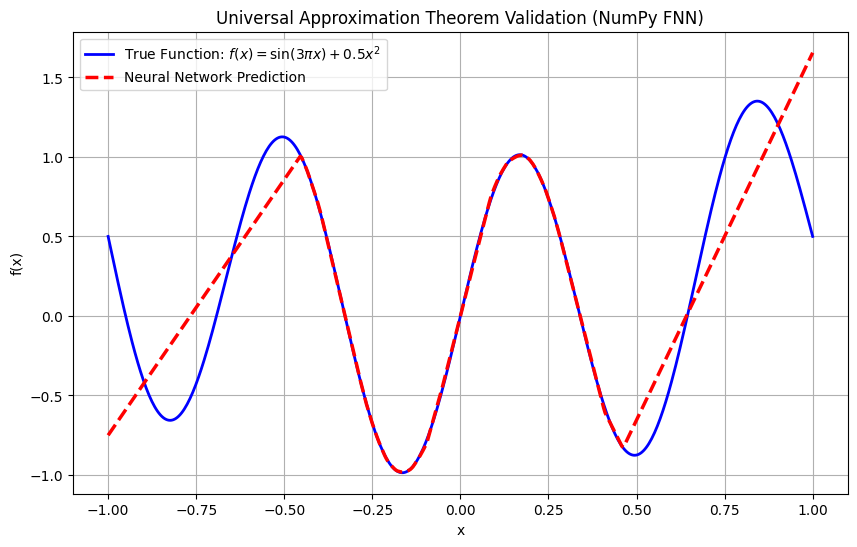

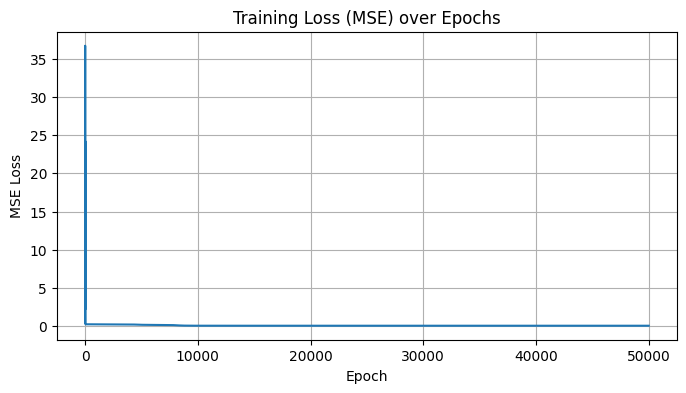

In [15]:
# 1. 计算测试集误差
_, _, _, y_test_pred = forward_prop(W1, b1, W2, b2, X_test)
test_mse = compute_mse(y_test_pred, y_test)
print(f"最终测试集 MSE: {test_mse:.6f}")

# 2. 获取连续点的预测值用于画图
_, _, _, y_plot_pred = forward_prop(W1, b1, W2, b2, X_plot)

# 3. 绘制拟合效果图
plt.figure(figsize=(10, 6))

# 绘制真实曲线
plt.plot(
    X_plot,
    y_plot_true,
    label="True Function: $f(x) = \sin(3\pi x) + 0.5x^2$",
    color="blue",
    linewidth=2,
)

# 绘制神经网络的预测曲线
plt.plot(
    X_plot,
    y_plot_pred,
    label="Neural Network Prediction",
    color="red",
    linestyle="--",
    linewidth=2.5,
)

# # 绘制部分测试集散点以展示数据分布
# plt.scatter(
#     X_test[:200], y_test[:200], color="gray", alpha=0.5, s=10, label="Test Data Samples"
# )

plt.title("Universal Approximation Theorem Validation (NumPy FNN)")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.legend()
plt.grid(True)
plt.show()

# 4. 绘制损失下降曲线
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss (MSE) over Epochs")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.grid(True)
plt.show()